In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense, LSTM, Input, Embedding, TextVectorization, Dropout
from tensorflow.keras.models import Model

In [2]:
df = pd.read_csv('/content/WELFake_Dataset.csv')

In [3]:
df.drop(['Unnamed: 0'], axis = 1, inplace = True)

In [4]:
df['text'] = df['text'].fillna('')
df['title'] = df['title'].fillna('')

In [5]:
# Combine title and text column into a single column and concatenate the string from title with text
df['news'] = (df['title']) + ' ' + (df['text'])
df['news'] = df['news'].fillna('')

In [6]:
y = df['label'].values
news = df['news'].values

In [7]:
len_arr = []
for i in news:
  len_arr.append(len(i.split()))

len_arr = np.array(len_arr)

In [8]:
np.median(len_arr)

np.float64(410.0)

In [9]:
max_len = max(len(i.split()) for i in news)

In [10]:
max_len

24243

In [11]:
sum_lens = sum(len(i.split()) for i in news)
avg_len = sum_lens / len(news)

In [12]:
avg_len

552.7242493137771

In [13]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(news, y, test_size=0.1, random_state=42, stratify=y)

In [14]:
MAX_WORDS = 50000
BATCH_SIZE = 64
MAX_LEN = 500

In [15]:
vectorize = TextVectorization(max_tokens=MAX_WORDS, output_sequence_length=MAX_LEN)

text_ds = tf.data.Dataset.from_tensor_slices(xtrain).batch(BATCH_SIZE)
vectorize.adapt(text_ds)

In [16]:
len(vectorize.get_vocabulary())

50000

In [17]:
K = 128

In [18]:
i = Input(shape=(1,), dtype=tf.string)
x = vectorize(i)
x = Embedding(MAX_WORDS, K)(x)
x = LSTM(128)(x)
x = Dropout(0.2)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(1, activation='sigmoid')(x)

model = Model(i, x)

In [19]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [20]:
train_ds = tf.data.Dataset.from_tensor_slices((xtrain, ytrain)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((xtest, ytest)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

model.fit(train_ds, epochs=5, validation_data=test_ds)

Epoch 1/5
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 43s 37ms/step - accuracy: 0.6499 - loss: 0.6113 - val_accuracy: 0.6594 - val_loss: 0.6040
Epoch 2/5
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 38s 37ms/step - accuracy: 0.8011 - loss: 0.3992 - val_accuracy: 0.9552 - val_loss: 0.1201
Epoch 3/5
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 37s 36ms/step - accuracy: 0.9759 - loss: 0.0724 - val_accuracy: 0.9799 - val_loss: 0.0660
Epoch 4/5
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 37s 36ms/step - accuracy: 0.9916 - loss: 0.0286 - val_accuracy: 0.9838 - val_loss: 0.0671
Epoch 5/5
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 37s 37ms/step - accuracy: 0.9963 - loss: 0.0136 - val_accuracy: 0.9818 - val_loss: 0.0762


In [21]:
model.predict(tf.constant([["WATCH JUDGE ORDER PUNK WEARING “POLICE LIE” T-SHIRT TO LEAVE COURTROOM…Or Face Contempt Charges The hate for our law enforcement is at an all time high. The blame for the injuries suffered and murders of innocent law enforcement officers falls squarely on the shoulders of Eric Holder, Eric Sharpton and Barack Hussein Obama "]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step


array([[0.9997508]], dtype=float32)

In [23]:
r = model.history

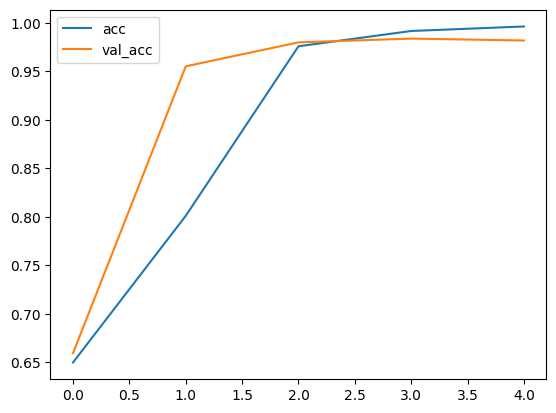

In [26]:
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

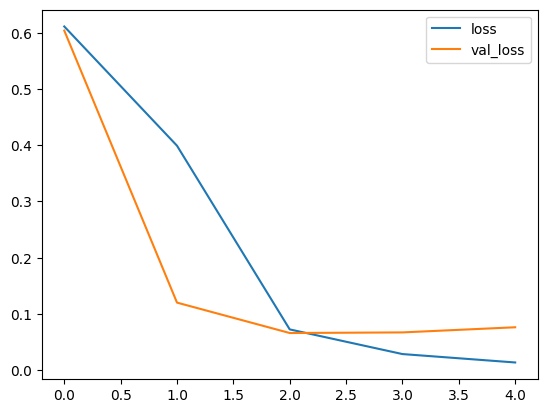

In [27]:
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()